# Convolutional Neural Networks

# Importar Librerías

In [71]:
%pip install scikit-learn
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from tensorflow.keras.layers import LeakyReLU

# Cargar set de Imágenes

In [72]:
dirname = os.path.join(os.getcwd(),'redimencionDataset_clean')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            if(len(image.shape)==3):
                
                images.append(image)
            b = "Leyendo..." + str(cant)
            print (b, end="\r")
            if prevRoot !=root:
                print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
C:\Users\itzel\AppData\Local\Temp\ipykernel_10904\1170484914.py:14: SyntaxWarning: invalid escape sequence '\.'
  if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):


leyendo imagenes de  c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\Animales\redimencionDataset_clean\
c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\Animales\redimencionDataset_clean\gato 1
c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\Animales\redimencionDataset_clean\hormiga 10000
c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\Animales\redimencionDataset_clean\mariquita 10000
c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\Animales\redimencionDataset_clean\perro 10000
c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\Animales\redimencionDataset_clean\tortuga 10000
Directorios leidos: 5
Imagenes en cada directorio [10001, 10000, 10000, 10000, 9999]
suma Total de imagenes en subdirs: 50000


# Creamos las etiquetas

In [73]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  50000


In [74]:
animales=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    animales.append(name[len(name)-1])
    indice=indice+1

0 gato
1 hormiga
2 mariquita
3 perro
4 tortuga


In [75]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  5
Output classes :  [0 1 2 3 4]


# Creamos Sets de Entrenamiento y Test

In [76]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (40000, 28, 28, 3) (40000,)
Testing data shape :  (10000, 28, 28, 3) (10000,)


Text(0.5, 1.0, 'Ground Truth : 3')

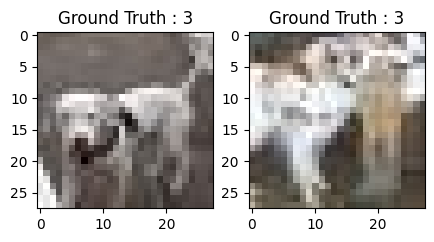

In [77]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

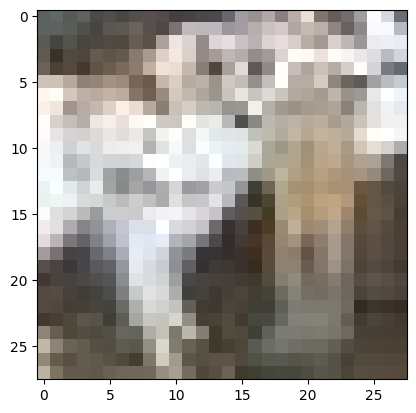

In [78]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [79]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 3
After conversion to one-hot: [0. 0. 0. 1. 0.]


# Creamos el Set de Entrenamiento y Validación

In [80]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [81]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(32000, 28, 28, 3) (8000, 28, 28, 3) (32000, 5) (8000, 5)


# Creamos el modelo de CNN

In [82]:
INIT_LR = 1e-3 
epochs = 50
batch_size = 64 

In [83]:
print(epochs)
print(type(epochs))

50
<class 'int'>


In [84]:
sport_model = Sequential()

sport_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(28, 28, 3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2),padding='same'))

sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))

sport_model.add(Conv2D(128, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))

sport_model.add(Flatten())

sport_model.add(Dense(64, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))

sport_model.add(Dropout(0.4)) 

sport_model.add(Dense(nClasses, activation='softmax'))

c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\itzel\OneDrive\Escritorio\IA\Proyectos\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [85]:
sport_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,709 (877.77 KB)

 Trainable params: 224,709 (877.77 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
sport_model.compile(loss='categorical_crossentropy', 
                    optimizer='adam', 
                    metrics=['accuracy'])

In [87]:
# El 'patience' define cuántas épocas esperar por una mejora antes de detenerse
# Basado en tus gráficas, el pico fue en la época 8, por lo que 10 de paciencia es seguro.
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    min_delta=0.001, # Mejora mínima requerida para ser considerada una mejora
    mode='min', 
    verbose=1
)

callbacks_list = [early_stopping]

# Entrenamos el modelo: Aprende a clasificar imágenes

In [88]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label),callbacks=callbacks_list)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.6024 - loss: 0.9558 - val_accuracy: 0.6826 - val_loss: 0.7668
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.7029 - loss: 0.7195 - val_accuracy: 0.7337 - val_loss: 0.6504
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.7415 - loss: 0.6285 - val_accuracy: 0.7502 - val_loss: 0.6040
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7668 - loss: 0.5693 - val_accuracy: 0.7360 - val_loss: 0.6555
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7926 - loss: 0.5145 - val_accuracy: 0.7811 - val_loss: 0.5457
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8087 - loss: 0.4707 - val_accuracy: 0.7856 - val_loss: 0.5387
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8253 - loss: 0.4272 - val_accuracy: 0.7834 - val_loss: 0.5435
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.8422 - loss: 0.3888 - 

# Evaluamos la red

In [89]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("Modelos/modelo1.h5")

In [90]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7653 - loss: 0.9633


In [91]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.9632723927497864
Test accuracy: 0.7652999758720398


In [92]:
sport_train.history

{'accuracy': [0.6024374961853027,
  0.702875018119812,
  0.741531252861023,
  0.7668125033378601,
  0.7926250100135803,
  0.8087499737739563,
  0.8253437280654907,
  0.8422499895095825,
  0.8561875224113464,
  0.8690624833106995,
  0.8852187395095825,
  0.8989375233650208,
  0.9108750224113464,
  0.9203125238418579,
  0.9248437285423279,
  0.9412187337875366],
 'loss': [0.9557837843894958,
  0.7194810509681702,
  0.6285331845283508,
  0.5692594051361084,
  0.5145208835601807,
  0.4707348644733429,
  0.42715469002723694,
  0.3888496458530426,
  0.3481552302837372,
  0.317033052444458,
  0.28269585967063904,
  0.24968691170215607,
  0.22237858176231384,
  0.20175160467624664,
  0.1911151260137558,
  0.15257170796394348],
 'val_accuracy': [0.6826249957084656,
  0.7337499856948853,
  0.750249981880188,
  0.7360000014305115,
  0.781125009059906,
  0.7856249809265137,
  0.7833750247955322,
  0.7846249938011169,
  0.7853749990463257,
  0.7836250066757202,
  0.7847499847412109,
  0.78437501192

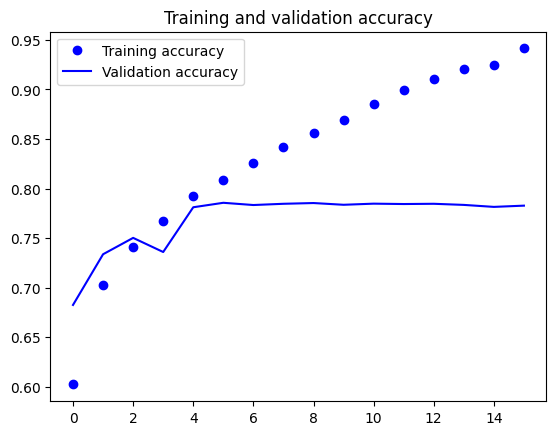

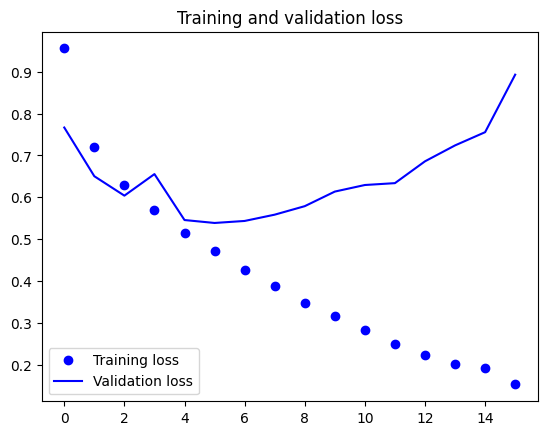

In [93]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [94]:
predicted_classes2 = sport_model.predict(test_X)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [95]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [96]:
predicted_classes.shape, test_Y.shape

((10000,), (10000,))

# Aprendamos de los errores: Qué mejorar

Found 7653 correct labels


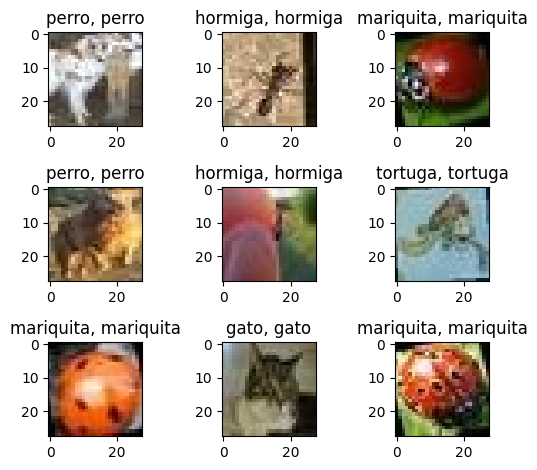

In [97]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(28,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[correct]],
                                                    animales[test_Y[correct]]))

    plt.tight_layout()

Found 2347 incorrect labels


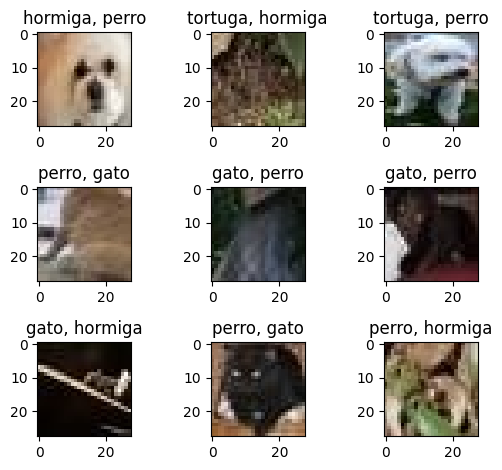

In [98]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(28,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[incorrect]],
                                                    animales[test_Y[incorrect]]))
    plt.tight_layout()

In [99]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.61      0.56      0.59      2026
     Class 1       0.77      0.88      0.82      1981
     Class 2       0.98      0.97      0.97      1954
     Class 3       0.62      0.57      0.59      2046
     Class 4       0.83      0.86      0.85      1993

    accuracy                           0.77     10000
   macro avg       0.76      0.77      0.76     10000
weighted avg       0.76      0.77      0.76     10000



In [124]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.models import load_model


test_dir = 'test_images'
modelo_h5 = 'Modelos/modelo1.h5'
sriesgos = ['gatos', 'hormigas', 'mariquitas', 'perros', 'tortugas']
image_extensions = re.compile(r"\.(jpg|jpeg|png|bmp|tiff|WEBP)$", re.IGNORECASE)

try:
    riesgo_model = load_model(modelo_h5)
    print("Modelo cargado exitosamente.")
except Exception as e:
    print(f"ERROR: No se pudo cargar el modelo. {e}")
    exit()

images = []
filenames_found = []

print(f"\nBuscando imágenes en: {test_dir}")
for filename in os.listdir(test_dir):
    # 🌟 CORRECCIÓN CRÍTICA: Solo procesamos archivos de imagen
    if image_extensions.search(filename):
        filepath = os.path.join(test_dir, filename)
        filenames_found.append(filename)
        
        try:
            image = plt.imread(filepath)
            
            if len(image.shape) == 3:
                image_resized = resize(image, (28, 28), anti_aliasing=True, clip=False, preserve_range=True)
                images.append(image_resized)
            
            
        except Exception as e:
            print(f"Error al leer/procesar {filename}. Error: {e}")

if not images:
    print("\nNo se encontraron imágenes válidas o se falló al leer todas.")
else:

    X = np.array(images, dtype=np.uint8) 
    test_X = X.astype('float32')
    test_X = test_X / 255.

    predicted_classes = riesgo_model.predict(test_X) 
    predicted_labels = np.argmax(predicted_classes, axis=1)

    print("\n--- Resultados---")
    for i, label_index in enumerate(predicted_labels):
        print(f"{filenames_found[i]}  {sriesgos[label_index]}")

Modelo cargado exitosamente.

Buscando imágenes en: test_images
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step

--- Resultados---
descargar (2).jpeg  mariquitas
descargar (3).jpeg  perros
descargar (4).jpeg  perros
descargar (5).jpeg  gatos
descargar (6).jpeg  perros
